## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов.

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки.

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины.

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [3]:
df = pd.read_parquet('/content/drive/MyDrive/hw_1_marketplace_data.parquet')

In [4]:
df.head(20)

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN
5,50,4844708827,2025-04-01 22:48:21,Mobile,web,urals,organic,fashion,view_item,162222.0,NaN,NaN
6,50,4844708827,2025-04-01 22:48:26,Mobile,web,urals,organic,fashion,add_to_favorites,162222.0,NaN,NaN
7,50,4844708827,2025-04-01 22:02:48,Mobile,web,urals,organic,beauty,view_item,106520.0,NaN,NaN
8,50,6583713206,2025-04-01 12:50:01,Mobile,web,urals,organic,fashion,view_item,172530.0,NaN,NaN
9,50,6583713206,2025-04-01 12:16:01,Mobile,web,urals,organic,electronics,view_item,199987.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику.
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

In [5]:
df['event_ts'] = pd.to_datetime(df['event_ts'])
df['date'] = df['event_ts'].dt.date

In [6]:
# your code is here
sessions_per_day = df.groupby('date')['session_id'].nunique()
sessions_per_day

,session_id
date,
2025-04-01,2373
2025-04-02,2520
2025-04-03,2583
2025-04-04,2801
2025-04-05,3836
2025-04-06,3394
2025-04-07,2295
2025-04-08,2305
2025-04-09,2490


In [7]:
view_sessions = df[df['event'] == 'view_item'].groupby('date')['session_id'].nunique()
view_sessions

,session_id
date,
2025-04-01,1949
2025-04-02,2092
2025-04-03,2124
2025-04-04,2291
2025-04-05,3187
2025-04-06,2813
2025-04-07,1923
2025-04-08,1892
2025-04-09,2056


In [8]:
cart_sessions = df[df['event'] == 'add_to_cart'].groupby('date')['session_id'].nunique()
cart_sessions

,session_id
date,
2025-04-01,633
2025-04-02,677
2025-04-03,668
2025-04-04,764
2025-04-05,1049
2025-04-06,942
2025-04-07,647
2025-04-08,606
2025-04-09,706


In [9]:
purchase_sessions = df[df['event'] == 'purchase'].groupby('date')['session_id'].nunique()
purchase_sessions

,session_id
date,
2025-04-01,209
2025-04-02,208
2025-04-03,201
2025-04-04,215
2025-04-05,337
2025-04-06,279
2025-04-07,202
2025-04-08,183
2025-04-09,216


In [10]:
detection = pd.DataFrame({
    'sessions': sessions_per_day,
    'view_sessions': view_sessions,
    'cart_sessions': cart_sessions,
    'purchase_sessions': purchase_sessions
}).fillna(0)
detection

,sessions,view_sessions,cart_sessions,purchase_sessions
date,,,,
2025-04-01,2373,1949,633,209
2025-04-02,2520,2092,677,208
2025-04-03,2583,2124,668,201
2025-04-04,2801,2291,764,215
2025-04-05,3836,3187,1049,337
2025-04-06,3394,2813,942,279
2025-04-07,2295,1923,647,202
2025-04-08,2305,1892,606,183
2025-04-09,2490,2056,706,216


In [11]:
detection['view_to_purchase'] = detection['purchase_sessions']/detection['view_sessions']
detection['view_to_cart'] = detection['cart_sessions']/detection['view_sessions']
detection['cart_to_purchase'] = detection['purchase_sessions']/detection['cart_sessions']

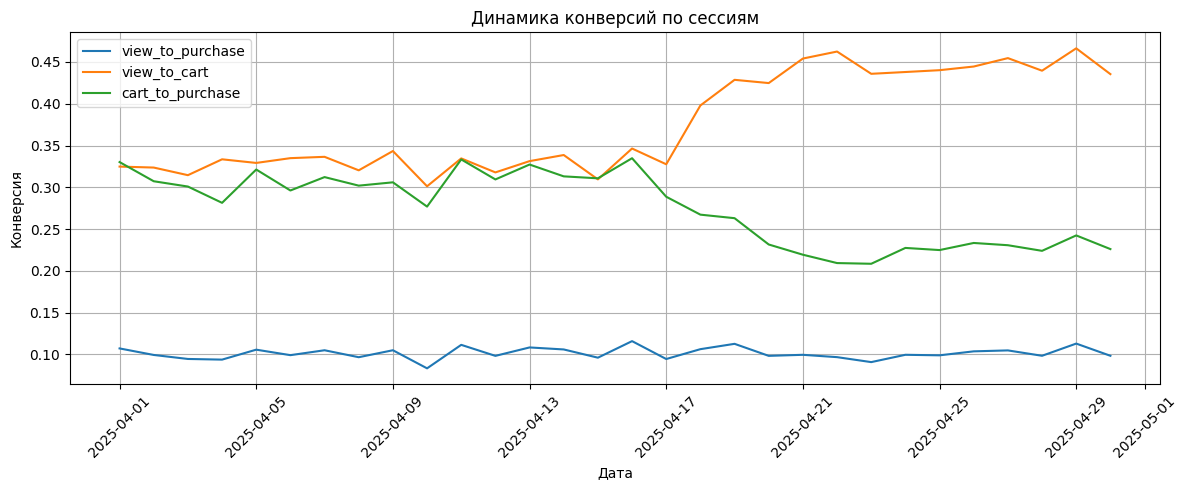

In [13]:
detection[['view_to_purchase', 'view_to_cart', 'cart_to_purchase']].plot(
    figsize=(12, 5))
plt.title('Динамика конверсий по сессиям')
plt.ylabel('Конверсия')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

На графике видно, что до 16 апреля все три конверсии +- стабильны. view_to_cart около 0.30-0.35, cart_to_purchase около 0.28-0.33, view_to_purchase около 0.10. Но примерно с 16-17 апреля view_to_cart резко возрастает с 0.33 до 0.45, а cart_to_purchase падает с 0.31 до 0.21. При этом итоговая конверсия view_to_purchase практически не меняется. Т.е корзина стала больше/чаще заполняться, но при этом до покупки это не доходит. Необходимо понять причину

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя.
3) На каком этапе воронки появилась проблема?

In [15]:
# your code is here
#Абсолютные значения
absevents = pd.DataFrame({
    'views': df[df['event'] == 'view_item'].groupby('date').size(),
    'add_to_cart': df[df['event'] == 'add_to_cart'].groupby('date').size(),
    'purchases': df[df['event'] == 'purchase'].groupby('date').size()
}).fillna(0)
absevents

,views,add_to_cart,purchases
date,,,
2025-04-01,4512,729,218
2025-04-02,4834,763,213
2025-04-03,4905,778,207
2025-04-04,5328,867,227
2025-04-05,7378,1220,350
2025-04-06,6523,1062,283
2025-04-07,4506,752,207
2025-04-08,4427,687,187
2025-04-09,4792,806,218


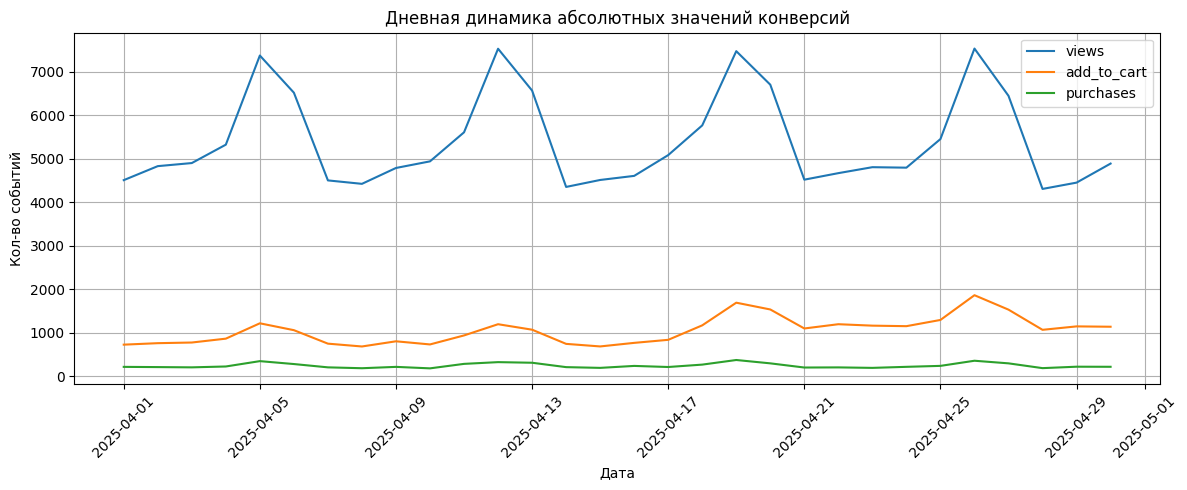

In [16]:
absevents.plot(figsize=(12, 5))
plt.title('Дневная динамика абсолютных значений конверсий')
plt.ylabel('Кол-во событий')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Средние значения, тут я все посмотрю, в том числе добавление в избранное, удаление из корзины
events_per_user = (
    df.groupby(['date', 'event'])
      .size()
      .unstack(fill_value=0)
      .div(df.groupby('date')['user_id'].nunique(), axis=0)
      )
events_per_user

event,add_to_cart,add_to_favorites,purchase,remove_from_cart,search,view_item
date,,,,,,
2025-04-01,0.461101,0.423782,0.137887,0.032891,0.757116,2.853890
2025-04-02,0.468386,0.432781,0.130755,0.035605,0.775322,2.967465
2025-04-03,0.472374,0.432908,0.125683,0.039466,0.791743,2.978142
2025-04-04,0.483278,0.395206,0.126533,0.036232,0.766444,2.969900
2025-04-05,0.543188,0.484417,0.155833,0.039626,0.862867,3.284951
2025-04-06,0.525223,0.464392,0.139960,0.039565,0.824431,3.226014
2025-04-07,0.497354,0.428571,0.136905,0.039021,0.732804,2.980159
2025-04-08,0.454365,0.395503,0.123677,0.031746,0.771825,2.927910
2025-04-09,0.487304,0.452237,0.131802,0.044135,0.758767,2.897219


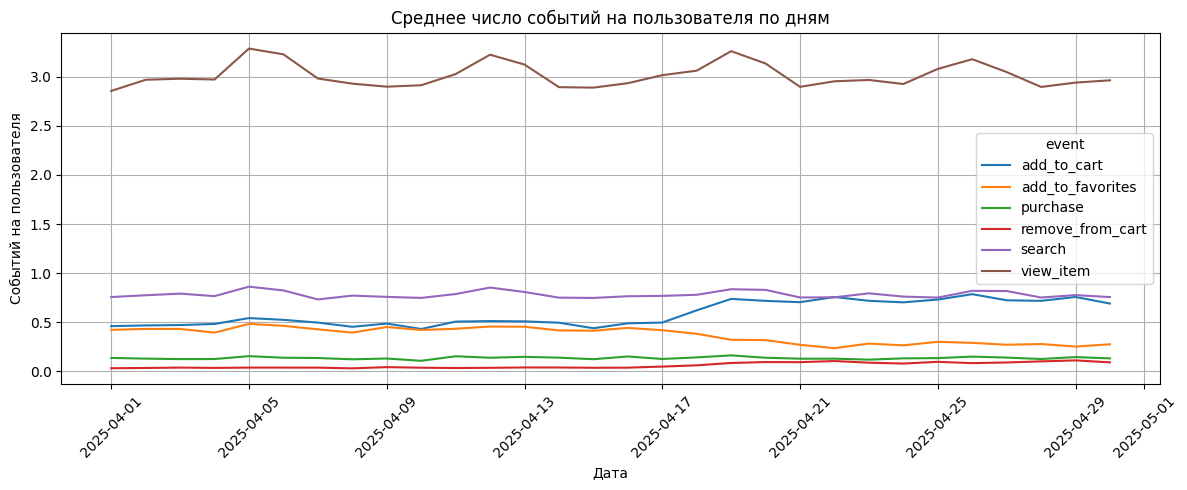

In [ ]:
events_per_user.plot(figsize=(12, 5))
plt.title('Среднее число событий на пользователя по дням')
plt.ylabel('Событий на пользователя')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Проблема заметна на этапе добавления в корзину (add_to_cart).

1. add_to_cart на пользователя резко вырос после 16-17 апреля, те пользователи стали чаще добавлять товары в корзину

2. НО!! add_to_favorites упал. Кажется, что пользователи стали использовать корзину вместо избранного

3. Еще! remove_from_cart вырос. Значит, часть этих добавлений убирается, пользователи добавляют (скорее всего, кнопка добавления в избранное недоступна), а потом убирают

4. purchase не вырос, те до покупки это не доходит

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

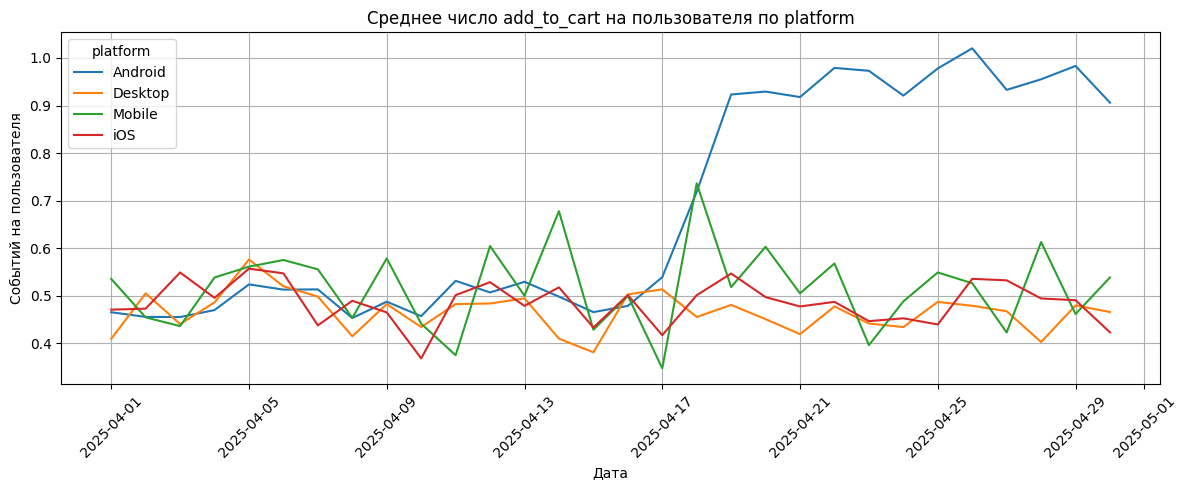

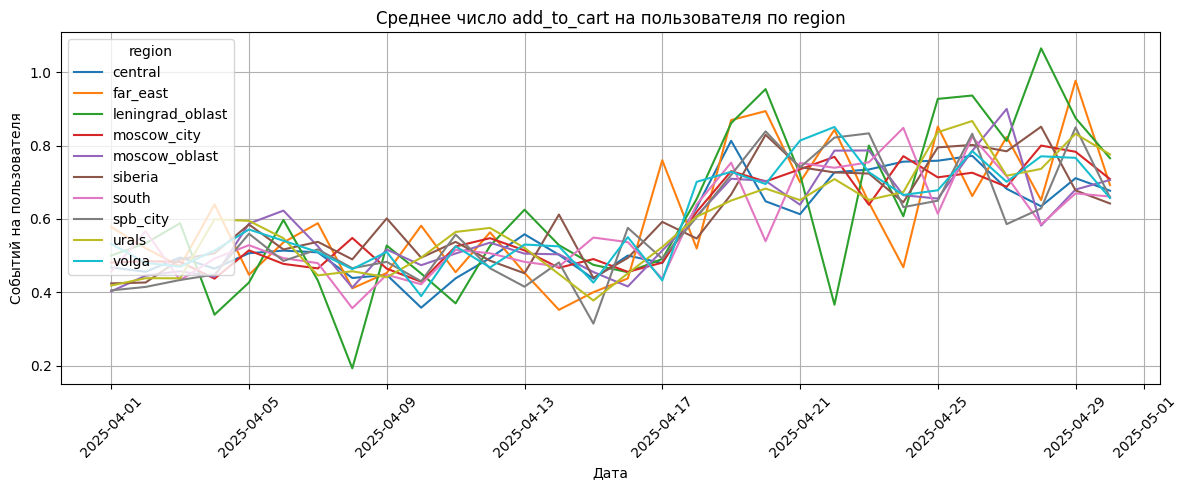

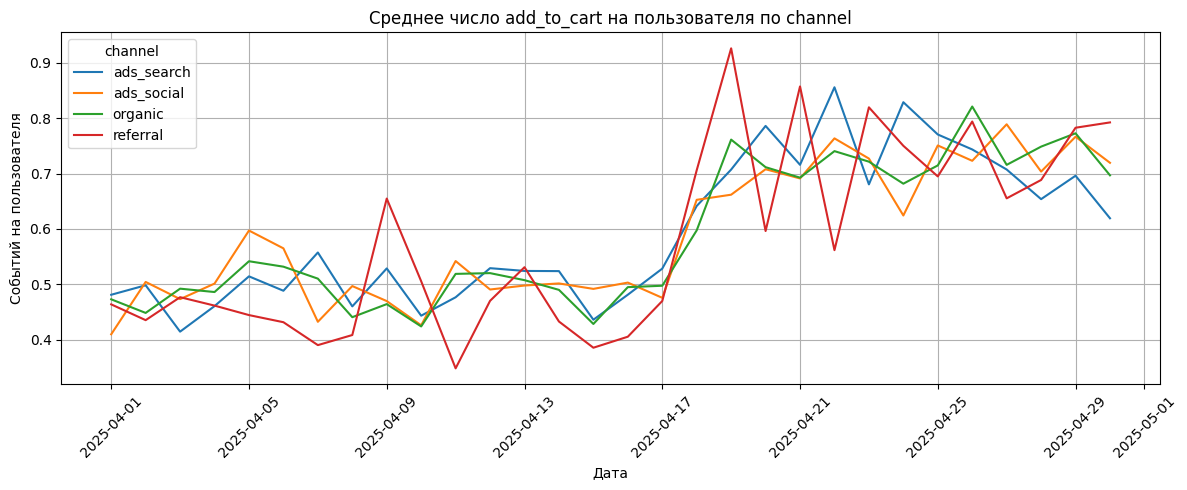

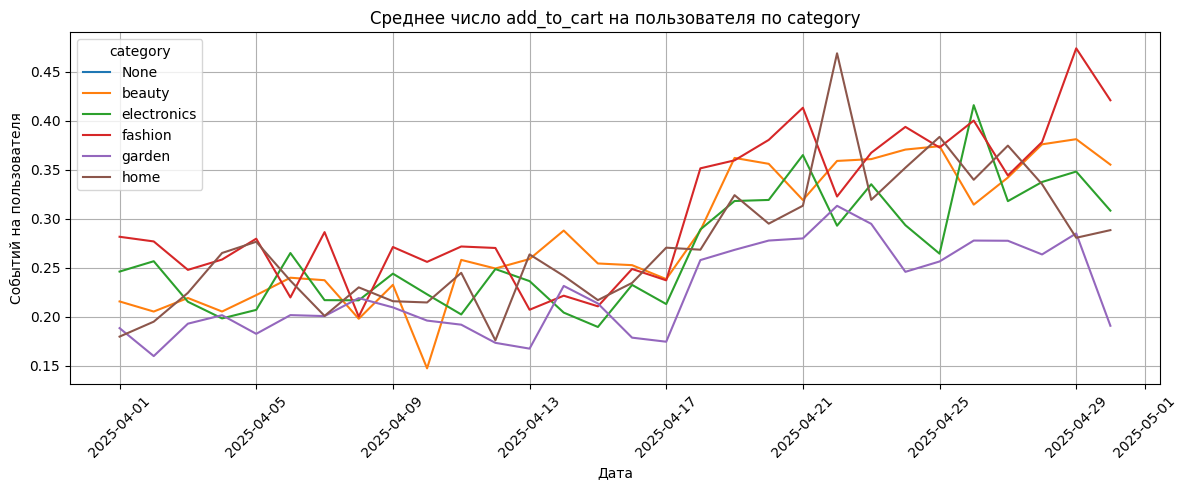

In [26]:
# your code is here
# Событие, у которого подскочило среднее на пользователя - add_to_cart
# Строю динамику add_to_cart на пользователя в разрезах, при этом я беру пользователя внутри кажлого среза,
#т.е знаменатель - уник. пользователи, которорые пришли из этого среза в этот день
# platform, region, channel, category. Чтобы было лаконичнее, оберну в функцию

event = 'add_to_cart'
sub = df[df['event'] == event]

def plot_avg_per_user(col):
    events = sub.groupby(['date', col]).size().rename('n_events')
    users = df.groupby(['date', col])['user_id'].nunique().rename('n_users')
    res = pd.concat([events, users], axis=1)
    res['per_user'] = res['n_events'] / res['n_users']
    res = res['per_user'].unstack(fill_value=0)

    res.plot(figsize=(12, 5))
    plt.title(f'Среднее число {event} на пользователя по {col}')
    plt.ylabel('Событий на пользователя')
    plt.xlabel('Дата')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_avg_per_user('platform')
plot_avg_per_user('region')
plot_avg_per_user('channel')
plot_avg_per_user('category')

По разрезу платформ выделяется Android. **Нужно обратить внимание!**

По регионам выделяющегося среза нет

По каналам не выделяется

По категориям выделяющегося среза тоже нет

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

In [20]:
# your code is here
# Событие - add_to_cart, метрика - среднее на пользователя
# Строю отдельно для iOS и Android с разложением по app_version

event = 'add_to_cart'
sub = df[df['event'] == event]

In [27]:
def plot_versions(platform):
    events = sub[sub['platform'] == platform].groupby(['date', 'app_version']).size().rename('n_events')
    users = df[df['platform'] == platform].groupby(['date', 'app_version'])['user_id'].nunique().rename('n_users')

    res = pd.concat([events, users], axis=1)
    res['per_user'] = res['n_events']/res['n_users']
    res = res['per_user'].unstack(fill_value=0)

    res.plot(figsize=(12, 5))
    plt.title(f'Среднее число {event} на пользователя {platform} по версиям')
    plt.ylabel('Событий на пользователя')
    plt.xlabel('Дата')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

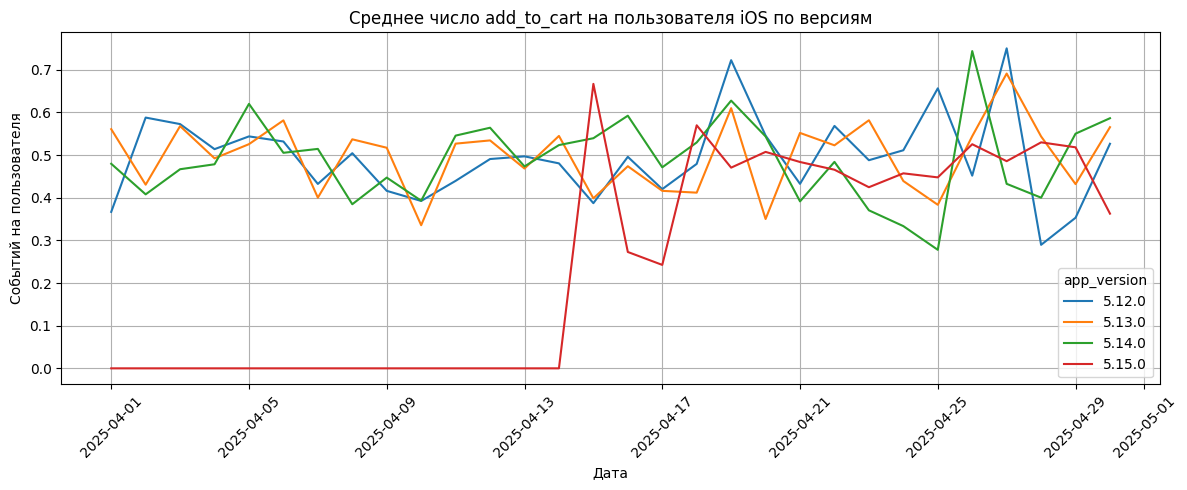

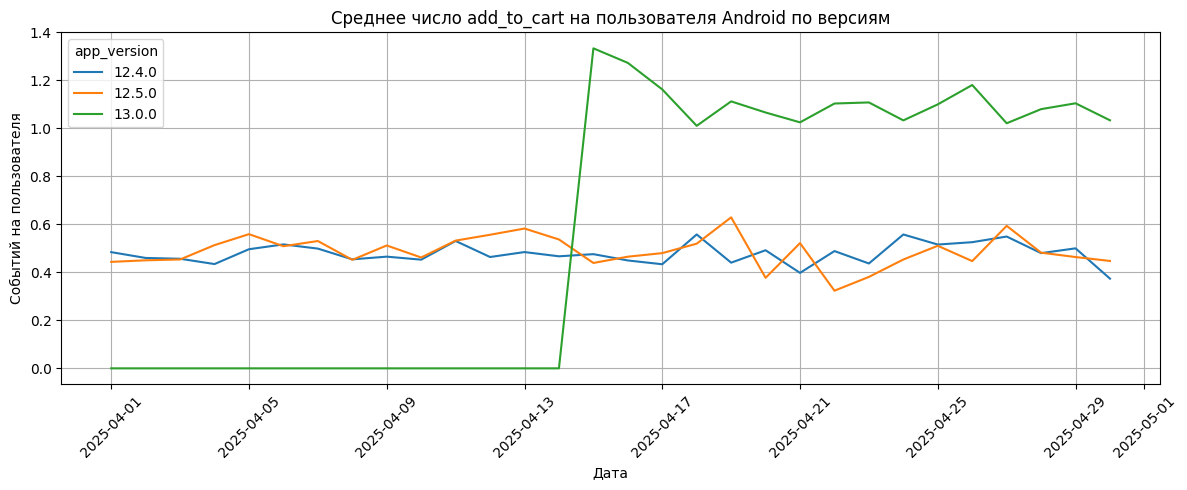

In [28]:
plot_versions('iOS')
plot_versions('Android')

Помогло локализовать проблему, если посмотреть на график по андроид версиям, видно в 13 версии сильно увеличилось число добавлений в корзину, версия неудачная

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

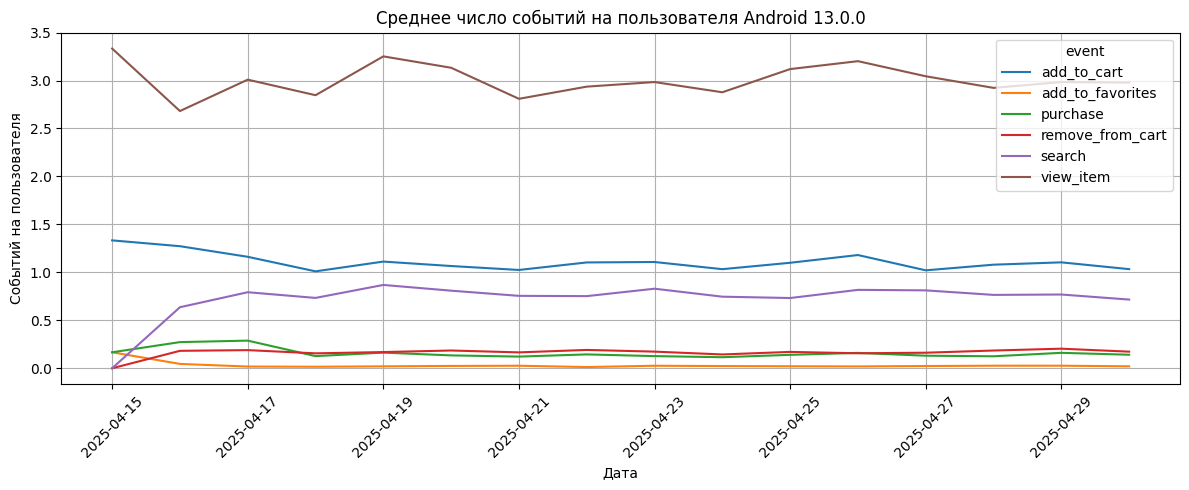

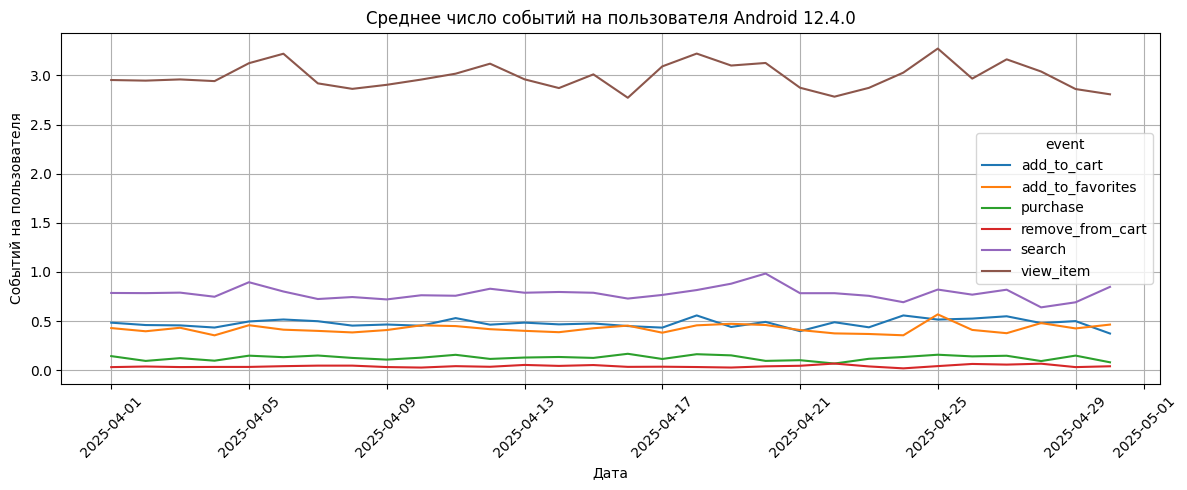

In [29]:
# your code is here
# Проблемная платформа - Android (там эффект сильнее всего).

platform = 'Android'
plat_df = df[df['platform'] == platform]

def plot_all_events_by_version(version):
    ver_df = plat_df[plat_df['app_version'] == version]

    events = ver_df.groupby(['date', 'event']).size().rename('n_events')
    users = ver_df.groupby('date')['user_id'].nunique().rename('n_users')
    res = events.div(users, level='date')

    res = res.unstack(fill_value=0)

    res.plot(figsize=(12, 5))
    plt.title(f'Среднее число событий на пользователя Android {version}')
    plt.ylabel('Событий на пользователя')
    plt.xlabel('Дата')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# сломанная версия и предыдущая (эталон)
plot_all_events_by_version('13.0.0')
plot_all_events_by_version('12.4.0')

На графиках по Android видно, что add_to_favorites резко падает с 0.2 до почти 0. Одновременно add_to_cart вырастает и remove_from_cart тоже. Пользователи стали заменять один функционал другим

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

**Резюме проведенного исследования**

**Что случилось.**

15 апреля вышло новая версия приложения - Android 13.0.0.
С этого дня число добавлений в избранное на пользователя (add_to_favorites) падает в 20 раз (с 0.4 до 0.02).

Примерно с 16-17 апреля view_to_cart резко возрастает с 0.33 до 0.45, а cart_to_purchase падает с 0.31 до 0.21. При этом итоговая конверсия view_to_purchase практически не меняется. То есть корзина стала больше/чаще заполняться, но при этом до покупки это не доходит.

**Как отреагировали пользователи.**

Лишившись возможности сохранять товары, пользователи стали замещать избранное другими механиками:

*   add_to_cart вырос примерно в 3 раза,
*   remove_from_cart тоже примерно в 3 раза.

Покупки в абсолюте не выросли. Рост корзины - не настоящий рост бизнеса, а искажение поведения из-за бага. Пользователи добавляют товары в корзину на сохранение, а потом удаляют.

**Где локализована проблема.**

По платформе: Android
По версии: только новые релизы от 15 апреля. Старые версии Android ведут себя нормально.
По регионам, каналам трафика и категориям товаров аномалий нет.

Это указывает на клиентский регресс UI, а не на проблему с трафиком или ассортиментом

**Гипотеза.**

В новых релизах пропала или сломалась кнопка Добавить в избранное, она не нажимается/перемещена или срабатывает как Добавить в корзину. Пользователи вынуждены сохранять товары через корзину.

**Рекомендации.**

1. Откатить или выпустить хотфикс для Android 13.0.0

2. Проверить UI этой версии, чтобы понять, где и как именно сломалась кнопка В избранное

После фикса убедиться, что add_to_cart и remove_from_cart вернулись к норме